In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


In [2]:
data = pd.read_csv('covid_19_data.csv')
data['ObservationDate'] = pd.to_datetime(data['ObservationDate'])
data = data.groupby(['ObservationDate', 'Country/Region']).sum().reset_index()
data = data[['ObservationDate', 'Country/Region', 'Confirmed', 'Deaths', 'Recovered']]

## Аналіз трендів захворюваності

In [3]:
latest_date = data['ObservationDate'].max()
data_latest = data[data['ObservationDate'] == latest_date]
data_prev = data[data['ObservationDate'] == latest_date - pd.Timedelta(days=7)]
data_trends = pd.merge(data_latest, data_prev, on='Country/Region', suffixes=('_latest', '_prev'))
data_trends['NewCases'] = data_trends['Confirmed_latest'] - data_trends['Confirmed_prev']
data_trends['Trend'] = np.where(data_trends['NewCases'] > 0, 'Спалах', 'Затухання')


## Вибір країн і даних для SIR-F

In [4]:
country_epidemic = data_trends[data_trends['Trend'] == 'Спалах'].iloc[0]['Country/Region']
country_recovery = data_trends[data_trends['Trend'] == 'Затухання'].iloc[0]['Country/Region']

def preprocess_country_data(country):
    country_data = data[data['Country/Region'] == country]
    country_data = country_data.groupby('ObservationDate').sum().reset_index()
    country_data['Infected'] = country_data['Confirmed'] - country_data['Deaths'] - country_data['Recovered']
    country_data = country_data[['ObservationDate', 'Infected', 'Recovered', 'Deaths']]
    return country_data

data_epidemic = preprocess_country_data(country_epidemic)
data_recovery = preprocess_country_data(country_recovery)


## Модель SIR-F

In [5]:
def sir_f_model(y, t, beta, gamma):
    S, I, R = y
    N = S + I + R
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return dSdt, dIdt, dRdt

def fit_sir_model(data):
    N = 1e6 
    I0 = data['Infected'].iloc[0]
    R0 = data['Recovered'].iloc[0]
    S0 = N - I0 - R0
    y0 = S0, I0, R0
    
    beta = 0.4
    gamma = 0.1
    t = np.arange(len(data))
    
    result = odeint(sir_f_model, y0, t, args=(beta, gamma))
    return t, result, beta, gamma

t_epidemic, result_epidemic, beta_epidemic, gamma_epidemic = fit_sir_model(data_epidemic)
t_recovery, result_recovery, beta_recovery, gamma_recovery = fit_sir_model(data_recovery)

In [6]:
forecast_days = [7, 30, 300]

def forecast_sir(t, result, beta, gamma, forecast_days):
    S, I, R = result[-1]
    t_future = np.arange(len(t), len(t) + max(forecast_days))
    future_result = odeint(sir_f_model, (S, I, R), t_future, args=(beta, gamma))
    forecasts = {day: future_result[day - 1] for day in forecast_days if day <= len(future_result)}
    return forecasts

forecast_epidemic = forecast_sir(t_epidemic, result_epidemic, beta_epidemic, gamma_epidemic, forecast_days)
forecast_recovery = forecast_sir(t_recovery, result_recovery, beta_recovery, gamma_recovery, forecast_days)

print("Прогноз для країни зі спалахом (Infected, Recovered, Fatal):")
for day, values in forecast_epidemic.items():
    print(f"Через {day} днів: I={values[1]:.0f}, R={values[2]:.0f}")

print("\nПрогноз для країни з затуханням (Infected, Recovered, Fatal):")
for day, values in forecast_recovery.items():
    print(f"Через {day} днів: I={values[1]:.0f}, R={values[2]:.0f}")


Прогноз для країни зі спалахом (Infected, Recovered, Fatal):
Через 7 днів: I=0, R=980173
Через 30 днів: I=0, R=980173
Через 300 днів: I=-0, R=980173

Прогноз для країни з затуханням (Infected, Recovered, Fatal):
Через 7 днів: I=0, R=980137
Через 30 днів: I=0, R=980137
Через 300 днів: I=-0, R=980137


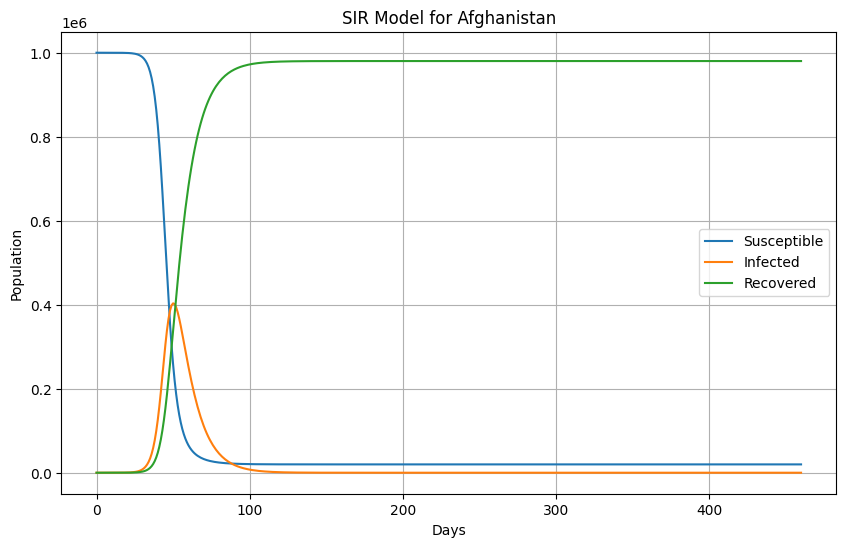

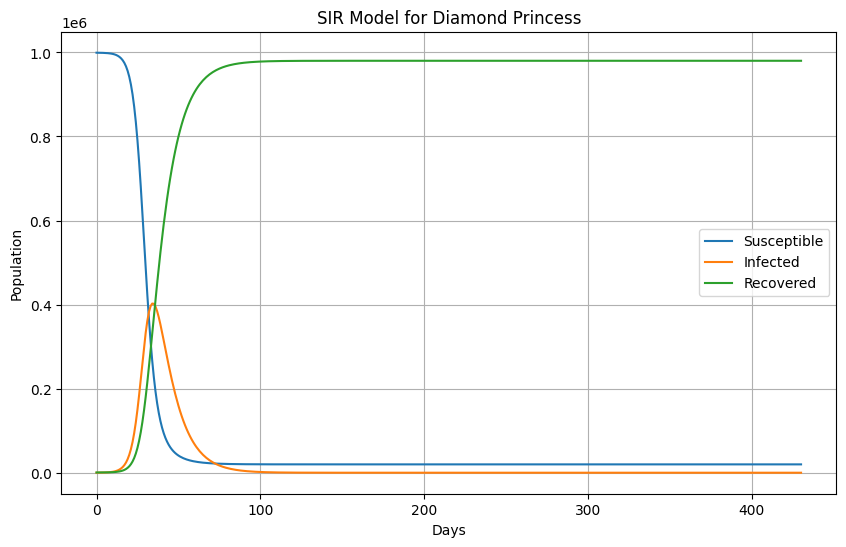

In [7]:
def plot_sir(t, result, country):
    S, I, R = result.T
    plt.figure(figsize=(10, 6))
    plt.plot(t, S, label='Susceptible')
    plt.plot(t, I, label='Infected')
    plt.plot(t, R, label='Recovered')
    plt.title(f"SIR Model for {country}")
    plt.xlabel("Days")
    plt.ylabel("Population")
    plt.legend()
    plt.grid()
    plt.show()

plot_sir(t_epidemic, result_epidemic, country_epidemic)
plot_sir(t_recovery, result_recovery, country_recovery)
